Lounes Guerrab Week 2 Internship Advencement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
import joblib

print('Libraries loaded OK')

Libraries loaded OK


Loading previous data:

In [7]:
TRAIN_PATH = 'data/UNSW_NB15_training-set/UNSW_NB15_training-set.csv'
TEST_PATH  = 'data/UNSW_NB15_testing-set/UNSW_NB15_testing-set.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

drop_cols = ['id', 'attack_cat']
for col in drop_cols:
    if col in train.columns:
        train.drop(col, axis=1, inplace=True)
        test.drop(col, axis=1, inplace=True)

cat_cols = train.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col]  = test[col].map(lambda x: x if x in le.classes_ else 'UNKNOWN')
    if 'UNKNOWN' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'UNKNOWN')
    test[col] = le.transform(test[col].astype(str))
    le_dict[col] = le

X_test = test.drop('label', axis=1)
y_test = test['label']


scaler = joblib.load('data/scaler.pkl')
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

models = {
    'Logistic Regression': joblib.load('data/Logistic_Regression_baseline.pkl'),
    'Random Forest':       joblib.load('data/Random_Forest_baseline.pkl'),
    'XGBoost':             joblib.load('data/XGBoost_baseline.pkl')
}

print(f'Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Models loaded: {list(models.keys())}')

Test set: 175341 samples, 42 features
Models loaded: ['Logistic Regression', 'Random Forest', 'XGBoost']


Fullfilling  the tables full of metrics:

In [ ]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'Accuracy':    round(accuracy_score(y, y_pred), 4),
        'Precision':   round(precision_score(y, y_pred), 4),
        'Recall':      round(recall_score(y, y_pred), 4),
        'F1-score':    round(f1_score(y, y_pred), 4),
        'ROC-AUC':     round(roc_auc_score(y, y_prob), 4),
        'Brier Score': round(brier_score_loss(y, y_prob), 4)
    }

results = {}
predictions = {}  

for name, model in models.items():
    X_eval = X_test_sc if name == 'Logistic Regression' else X_test
    results[name] = evaluate_model(model, X_eval, y_test)
    predictions[name] = {
        'y_pred': model.predict(X_eval),
        'y_prob': model.predict_proba(X_eval)[:, 1]
    }

df_results = pd.DataFrame(results).T
df_results.index.name = 'Model'

print('='*65)
print('  TABLE — Clean Baseline Performance (UNSW-NB15 test set)')
print('='*65)
print(df_results.to_string())
print()
print('Note: Brier Score → plus bas = mieux calibré (0 = parfait)')

  TABLE — Clean Baseline Performance (UNSW-NB15 test set)
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  Brier Score
Model                                                                           
Logistic Regression    0.8599     0.9714  0.8182    0.8882   0.9693       0.0961
Random Forest          0.9019     0.9888  0.8658    0.9232   0.9808       0.0734
XGBoost                0.9011     0.9879  0.8653    0.9225   0.9855       0.0823

Note: Brier Score → plus bas = mieux calibré (0 = parfait)


### Evaluation Metrics — Definitions & Formulas

**Accuracy** = (TP + TN) / (TP + TN + FP + FN)
Overall percentage of correct predictions. Can be misleading on imbalanced datasets

**Precision** = TP / (TP + FP)
When the model says "attack", how often is it right?

**Recall** = TP / (TP + FN)
Out of all real attacks, how many did the model catch? A missed attack (FN) is far more dangerous than a false alarm (FP).

**F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)
Harmonic mean of Precision and Recall.

**ROC-AUC** (Area Under the ROC Curve)
Measures the model's ability to separate attacks from benign traffic across all possible decision thresholds (not just 0.5). Ranges from 0.5 (random guessing) to 1.0 (perfect separation). Evaluated on predicted probabilities, not binary decisions.

**Brier Score** = (1/N) × Σ(predicted_probability − actual_outcome)²
Measures how well-calibrated the predicted probabilities are. Ranges from 0 (perfect) to 1 (worst). A well-calibrated model that predicts "80% attack" should be correct ~80% of the time. This matters for SafeML, which relies on probability outputs to compute statistical distances for drift detection.

> **Notation:** TP = True Positive (attack correctly detected), TN = True Negative (benign correctly classified), FP = False Positive (benign flagged as attack), FN = False Negative (attack missed).


Confusion matrice for all 3 models:

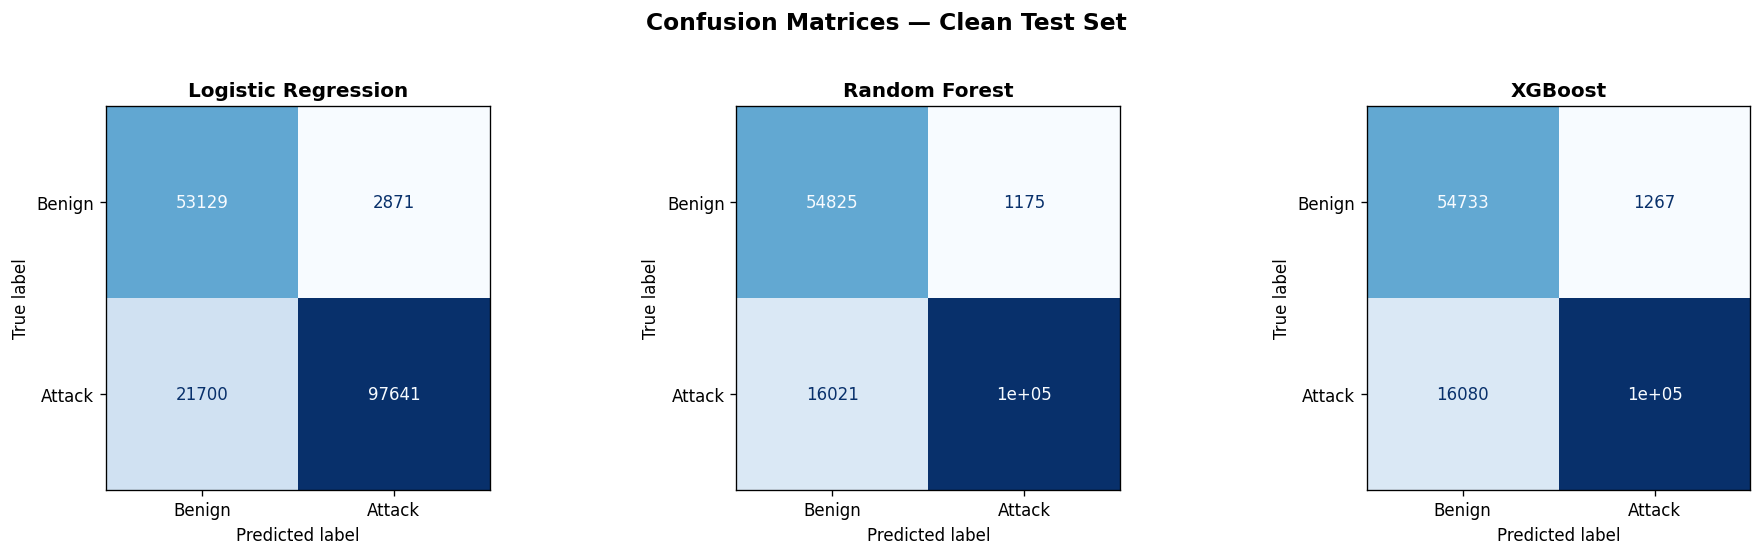

Saved: data/week2_confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')

fig.suptitle('Confusion Matrices — Clean Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/week2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week2_confusion_matrices.png')

ROC Curves:

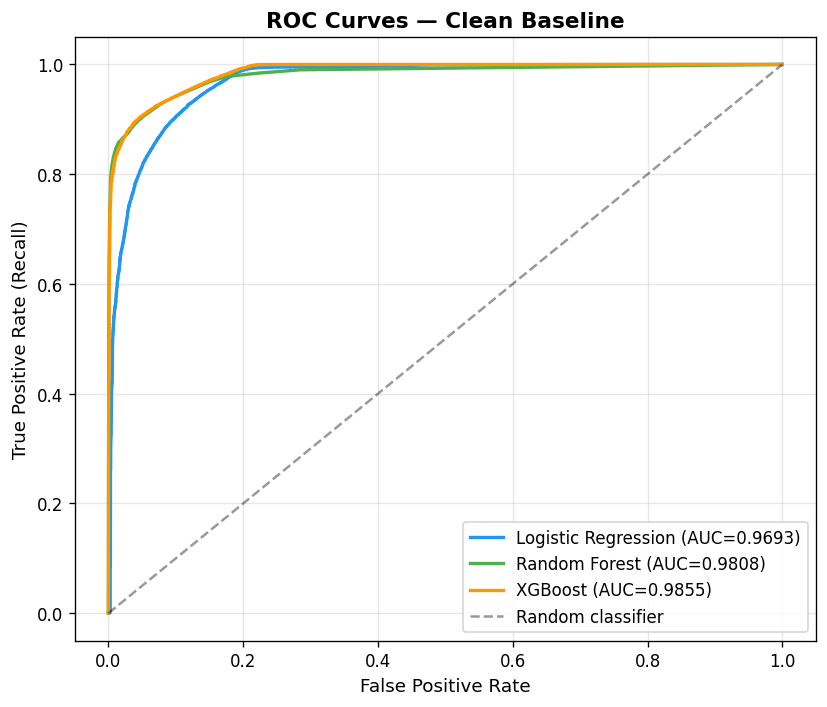

Saved: data/week2_roc_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800']
for (name, preds), color in zip(predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    auc = roc_auc_score(y_test, preds['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Clean Baseline', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/week2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week2_roc_curves.png')

---
### 4. Diagramme de calibration (Reliability Diagram)

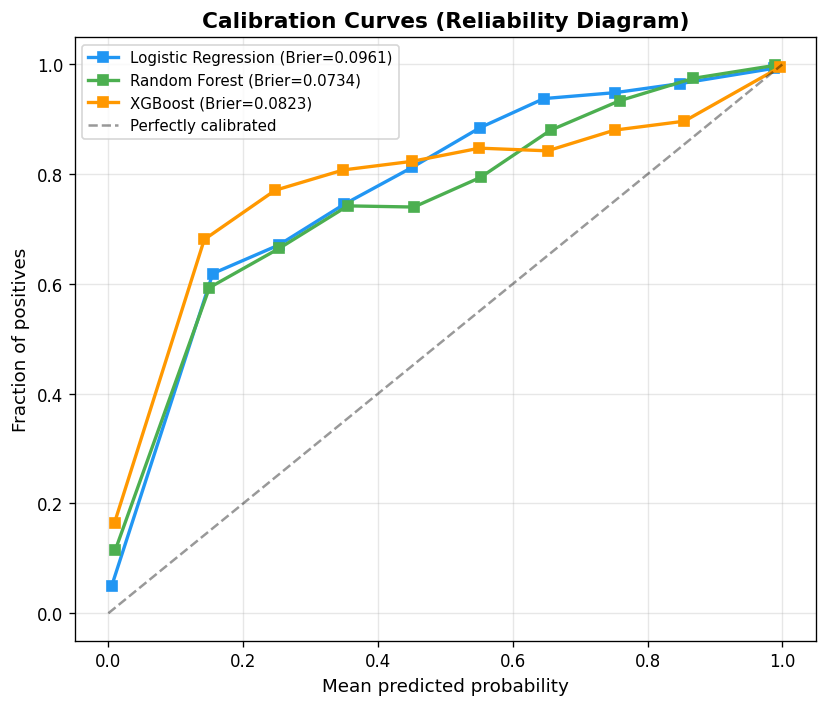

Saved: data/week2_calibration.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, preds), color in zip(predictions.items(), colors):
    prob_true, prob_pred = calibration_curve(y_test, preds['y_prob'], n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_test, preds['y_prob'])
    ax.plot(prob_pred, prob_true, 's-', color=color, linewidth=2,
            label=f'{name} (Brier={brier:.4f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability', fontsize=11)
ax.set_ylabel('Fraction of positives', fontsize=11)
ax.set_title('Calibration Curves (Reliability Diagram)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/week2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week2_calibration.png')

---
### 5. Bar chart comparatif des métriques

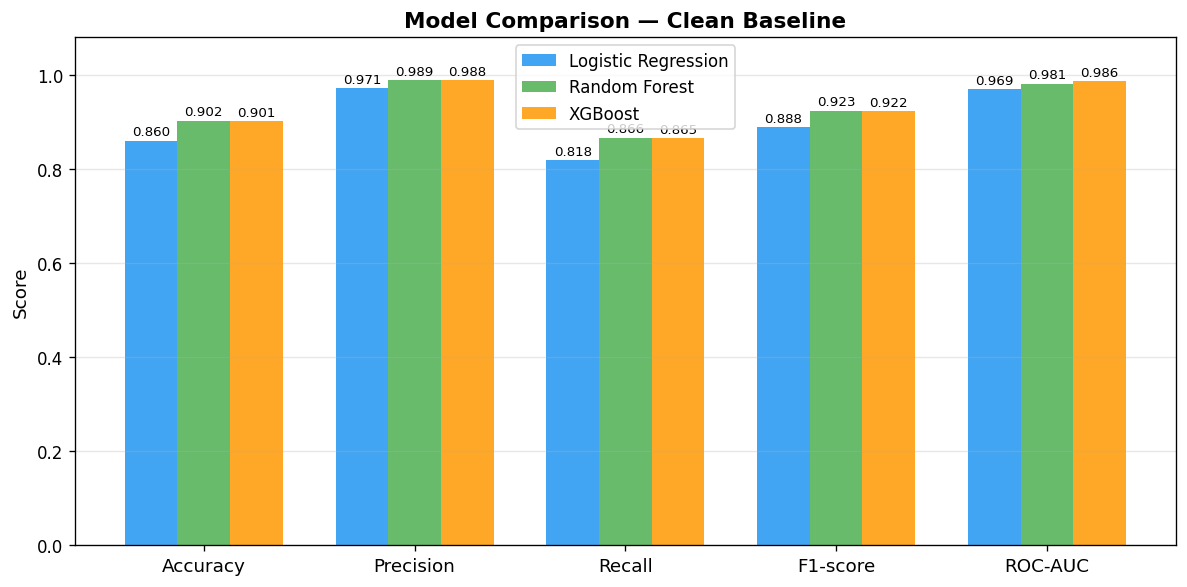

Saved: data/week2_metrics_comparison.png


In [12]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, color) in enumerate(zip(models.keys(), colors)):
    values = [results[name][m] for m in metrics_to_plot]
    bars = ax.bar(x + i*width, values, width, label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Clean Baseline', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/week2_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/week2_metrics_comparison.png')

---
### 6. Classification reports détaillés

In [13]:
for name, preds in predictions.items():
    print(f'\n{"="*55}')
    print(f'  Classification Report — {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, preds['y_pred'],
                                target_names=['Benign (0)', 'Attack (1)']))


  Classification Report — Logistic Regression
              precision    recall  f1-score   support

  Benign (0)       0.71      0.95      0.81     56000
  Attack (1)       0.97      0.82      0.89    119341

    accuracy                           0.86    175341
   macro avg       0.84      0.88      0.85    175341
weighted avg       0.89      0.86      0.86    175341


  Classification Report — Random Forest
              precision    recall  f1-score   support

  Benign (0)       0.77      0.98      0.86     56000
  Attack (1)       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341


  Classification Report — XGBoost
              precision    recall  f1-score   support

  Benign (0)       0.77      0.98      0.86     56000
  Attack (1)       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   ma

---
### 7. Sélection du modèle principal

On choisit le meilleur modèle selon ces critères de priorité :
1. **Recall** (détection d'attaques) — c'est la métrique la plus critique en cybersécurité
2. **F1-score** — équilibre recall/precision
3. **ROC-AUC** — capacité de discrimination globale
4. **Brier Score** — qualité de calibration des probabilités (utile pour SafeML)

In [14]:
print('='*60)
print('  MODEL SELECTION SUMMARY')
print('='*60)
print()

# Ranking par métrique
for metric in ['Recall', 'F1-score', 'ROC-AUC', 'Brier Score']:
    ascending = (metric == 'Brier Score')  # Brier: plus bas = mieux
    ranked = sorted(results.items(), key=lambda x: x[1][metric], reverse=not ascending)
    winner = ranked[0]
    print(f'  Best {metric:12s}: {winner[0]} ({winner[1][metric]:.4f})')

print()

# ----- Décision automatique basée sur le recall -----
best_model_name = max(results, key=lambda x: results[x]['Recall'])
print(f'  >>> SELECTED MODEL: {best_model_name}')
print(f'      Recall = {results[best_model_name]["Recall"]}')
print(f'      F1     = {results[best_model_name]["F1-score"]}')
print(f'      AUC    = {results[best_model_name]["ROC-AUC"]}')
print()
print('  Justification: In intrusion detection, maximizing recall')
print('  (attack detection rate) is critical — missed attacks (FN)')
print('  are more dangerous than false alarms (FP).')
print('  This model will be used for drift analysis in Week 3+.')
print('='*60)

  MODEL SELECTION SUMMARY

  Best Recall      : Random Forest (0.8658)
  Best F1-score    : Random Forest (0.9232)
  Best ROC-AUC     : XGBoost (0.9855)
  Best Brier Score : Random Forest (0.0734)

  >>> SELECTED MODEL: Random Forest
      Recall = 0.8658
      F1     = 0.9232
      AUC    = 0.9808

  Justification: In intrusion detection, maximizing recall
  (attack detection rate) is critical — missed attacks (FN)
  are more dangerous than false alarms (FP).
  This model will be used for drift analysis in Week 3+.
